<a href="https://colab.research.google.com/github/h-mutumwinka/linear_regression_model/blob/main/multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error

import joblib

In [103]:
df = pd.read_csv("https://raw.githubusercontent.com/h-mutumwinka/linear_regression_model/refs/heads/main/StudentPerformanceFactors.csv")

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [105]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [106]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


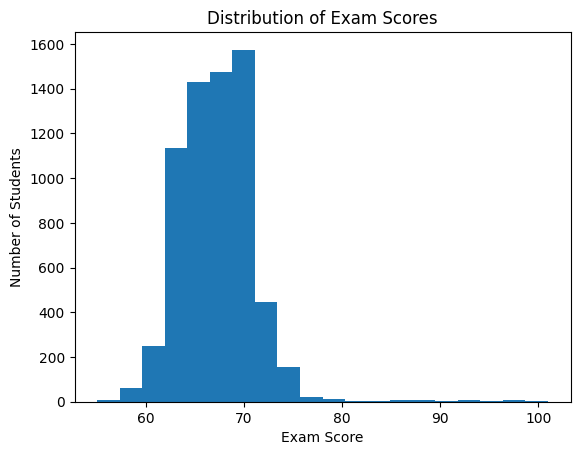

In [107]:
# histogram plot to see the varibales

plt.hist(df["Exam_Score"], bins=20)

plt.title("Distribution of Exam Scores")

plt.xlabel("Exam Score")

plt.ylabel("Number of Students")

plt.show()

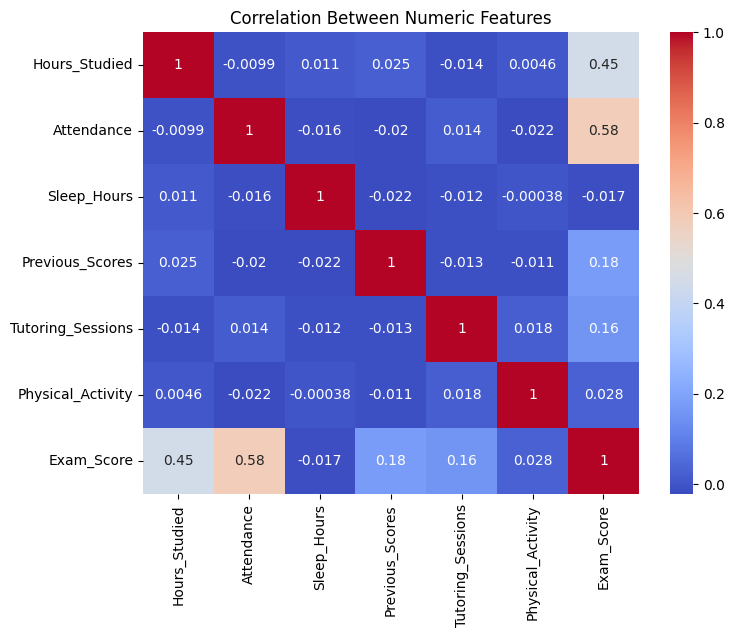

In [108]:
# Drawing correlation Heatmap to see which features affect exam score

df_numeric = df.select_dtypes(include=['int64', 'float64'])
corr = df_numeric.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Numeric Features")
plt.show()

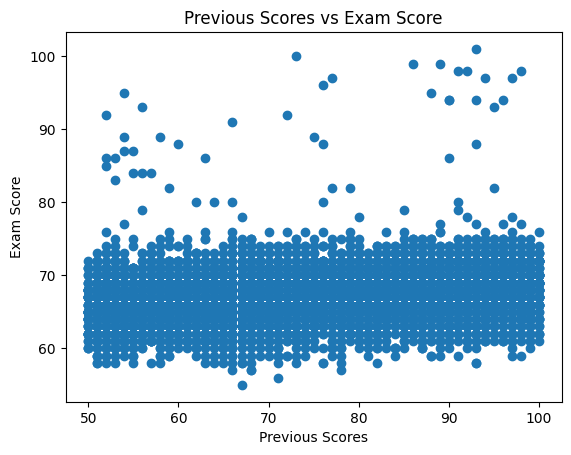

In [109]:
plt.scatter(df["Previous_Scores"], df["Exam_Score"])
plt.xlabel("Previous Scores")
plt.ylabel("Exam Score")
plt.title("Previous Scores vs Exam Score")
plt.show()

In [110]:

if 'student_id' in df.columns:
    df = df.drop('student_id', axis=1)


df = pd.get_dummies(df)
df.head()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Parental_Involvement_High,Parental_Involvement_Low,Parental_Involvement_Medium,...,Learning_Disabilities_No,Learning_Disabilities_Yes,Parental_Education_Level_College,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Far,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Female,Gender_Male
0,23,84,7,73,0,3,67,False,True,False,...,True,False,False,True,False,False,False,True,False,True
1,19,64,8,59,2,4,61,False,True,False,...,True,False,True,False,False,False,True,False,True,False
2,24,98,7,91,2,4,74,False,False,True,...,True,False,False,False,True,False,False,True,False,True
3,29,89,8,98,1,4,71,False,True,False,...,True,False,False,True,False,False,True,False,False,True
4,19,92,6,65,3,4,70,False,False,True,...,True,False,True,False,False,False,False,True,True,False


In [111]:
# I am goinf to predict Exam scores for the students
X = df.drop("Exam_Score", axis=1)
y = df["Exam_Score"]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [112]:
# I am going to calclutate Linear Regression, DecisionTree and RandomForest using Gradient Descent
LinearRegression_model = SGDRegressor(max_iter=1000, learning_rate='invscaling', eta0=0.01, random_state=42)
LinearRegression_model.fit(X_train, y_train)

DecisionTree_model = DecisionTreeRegressor(random_state=42)
DecisionTree_model.fit(X_train, y_train)


RandomForest_model = RandomForestRegressor(n_estimators=100, random_state=42)
RandomForest_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [113]:
lr_pred = LinearRegression_model.predict(X_test)
dt_pred = DecisionTree_model.predict(X_test)
rf_pred = RandomForest_model.predict(X_test)

print("Mean Squared Error (LR):", mean_squared_error(y_test, lr_pred))
print("Mean Squared Error (DT):", mean_squared_error(y_test, dt_pred))
print("Mean Squared Error (RF):", mean_squared_error(y_test, rf_pred))

Mean Squared Error (LR): 3.270501092686481
Mean Squared Error (DT): 10.21482602118003
Mean Squared Error (RF): 4.624625567322238


In [114]:
# calculting the mse_scores
mse_scores = {
    "Linear_Regression": mean_squared_error(y_test, lr_pred),
    "Decision_Tree": mean_squared_error(y_test, dt_pred),
    "Random_Forest": mean_squared_error(y_test, rf_pred)
}


best_model_name = min(mse_scores, key=mse_scores.get)
print("Best Model:", best_model_name)
print("MSE:", mse_scores[best_model_name])

if best_model_name == "Linear_Regression":
    best_model = LinearRegression_model
elif best_model_name == "Decision_Tree":
    best_model = DecisionTree_model
else:
    best_model = RandomForest_model

joblib.dump(best_model, "best_model.pkl")

Best Model: Linear_Regression
MSE: 3.270501092686481


['best_model.pkl']

In [115]:
model = joblib.load("best_model.pkl")

sample = X_test[0].reshape(1,-1)
prediction = model.predict(sample)

print("Predicted Math Score:", prediction[0])
print("Actual Math Score:", y_test.iloc[0])

Predicted Math Score: 64.48646578690399
Actual Math Score: 65


-- Epoch 1
Norm: 3.25, NNZs: 40, Bias: 67.182513, T: 5285, Avg. loss: 73.780716
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 3.31, NNZs: 40, Bias: 67.215837, T: 10570, Avg. loss: 2.239089
Total training time: 0.01 seconds.
-- Epoch 3
Norm: 3.26, NNZs: 40, Bias: 67.300686, T: 15855, Avg. loss: 2.228448
Total training time: 0.01 seconds.
-- Epoch 4
Norm: 3.30, NNZs: 40, Bias: 67.294753, T: 21140, Avg. loss: 2.222600
Total training time: 0.01 seconds.
-- Epoch 5
Norm: 3.33, NNZs: 40, Bias: 67.272970, T: 26425, Avg. loss: 2.225519
Total training time: 0.01 seconds.
-- Epoch 6
Norm: 3.31, NNZs: 40, Bias: 67.191332, T: 31710, Avg. loss: 2.218015
Total training time: 0.01 seconds.
-- Epoch 7
Norm: 3.32, NNZs: 40, Bias: 67.264922, T: 36995, Avg. loss: 2.222342
Total training time: 0.01 seconds.
-- Epoch 8
Norm: 3.29, NNZs: 40, Bias: 67.274058, T: 42280, Avg. loss: 2.212566
Total training time: 0.01 seconds.
-- Epoch 9
Norm: 3.28, NNZs: 40, Bias: 67.227573, T: 47565, Avg. loss: 2.220475


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stocha

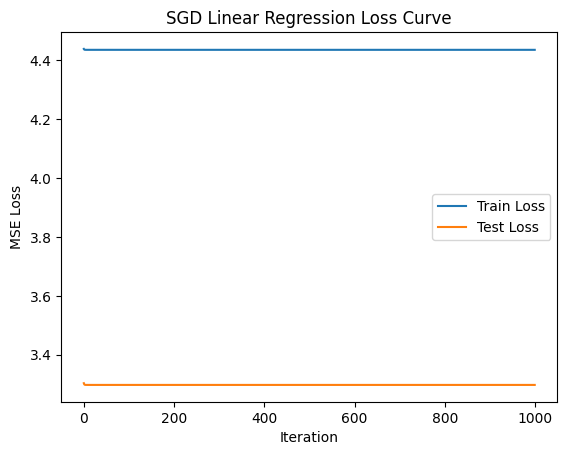

In [116]:
lr_model = SGDRegressor(max_iter=1000, learning_rate='invscaling', eta0=0.01, random_state=42, verbose=1)
lr_model.fit(X_train, y_train)


train_losses = []
test_losses = []

sgd = SGDRegressor(max_iter=1, learning_rate='constant', eta0=0.01, random_state=42, warm_start=True)

for i in range(1000):
    sgd.fit(X_train, y_train)
    train_pred = sgd.predict(X_train)
    test_pred = sgd.predict(X_test)
    train_losses.append(mean_squared_error(y_train, train_pred))
    test_losses.append(mean_squared_error(y_test, test_pred))

plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('SGD Linear Regression Loss Curve')
plt.legend()
plt.show()

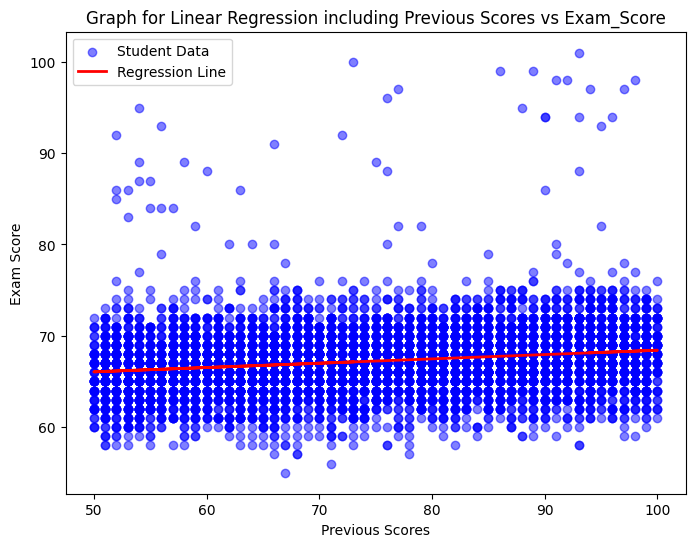

In [117]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = df[['Previous_Scores']]
y = df['Exam_Score']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

plt.figure(figsize=(8,6))
plt.scatter(X, y, color='blue', alpha=0.5, label='Student Data')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title("Graph for Linear Regression including Previous Scores vs Exam_Score")
plt.xlabel("Previous Scores")
plt.ylabel("Exam Score")
plt.legend()
plt.show()

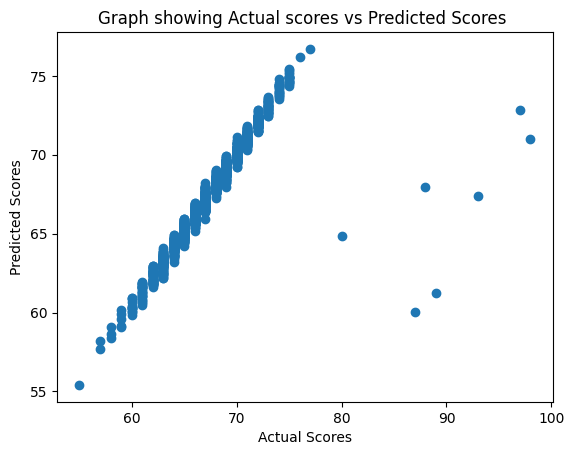

In [118]:
plt.scatter(y_test, lr_pred)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Graph showing Actual scores vs Predicted Scores ")
plt.show()